# Search the spatial transcriptomics atlas

**Aim.** Retrieve measured ST spots using natural-language and H&E image queries.

**Outputs.** Cosine-similarity rankings for text queries and ranked-gene overlap results for an image query in the public tutorial atlas subset.

## Installation

Create a Python 3.10+ environment, install the public HistAgent package and add
the lightweight analysis dependencies used by these notebooks.

```bash
git clone https://github.com/zipging/HistAgent.git
cd HistAgent
python -m venv .venv
source .venv/bin/activate
python -m pip install -e .
python -m pip install jupyter numpy pandas matplotlib seaborn scipy scikit-learn torch huggingface-hub
```

If `data/` is absent, the notebook downloads its data from
`wli13/HistAgent-data`. These examples run without a GPU. Running HistAgent on
new images requires access to the gated Prov-GigaPath model and an authenticated
Hugging Face session.

## Setup

Import the analysis packages, locate the tutorial data and set the plotting style.

In [1]:
from pathlib import Path
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

configured_data = os.getenv("HISTAGENT_TUTORIAL_DATA", "").strip()
DATA_DIR = Path(configured_data).expanduser() if configured_data else Path("data")
if not DATA_DIR.exists():
    from huggingface_hub import snapshot_download

    snapshot = Path(
        snapshot_download(
            "wli13/HistAgent-data",
            repo_type="dataset",
            allow_patterns=["tutorials/**", "manifest.json"],
        )
    )
    DATA_DIR = snapshot / "tutorials"
assert DATA_DIR.exists(), f"Tutorial data not found: {DATA_DIR}"

def rankridge_pack_root(groups):
    configured = os.getenv("HISTAGENT_RANKRIDGE_PACKS", "").strip()
    if configured:
        root = Path(configured).expanduser()
        if not (root / groups[0]).exists():
            root = root / "rankridge_tutorial_packs"
        assert (root / groups[0]).exists(), f"RankRidge pack not found: {root}"
        return root

    from huggingface_hub import snapshot_download

    snapshot = Path(
        snapshot_download(
            "wli13/HistAgent-data",
            repo_type="dataset",
            allow_patterns=[
                f"rankridge_tutorial_packs/{group}/**" for group in groups
            ],
        )
    )
    return snapshot / "rankridge_tutorial_packs"

sns.set_theme(style="white", context="talk")
plt.rcParams.update({
    "figure.dpi": 115,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#000000",
    "axes.labelcolor": "#000000",
    "axes.linewidth": 1.25,
    "axes.grid": False,
    "xtick.color": "#000000",
    "ytick.color": "#000000",
    "text.color": "#000000",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10.5,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.titlesize": 12,
})
COLORS = {
    "HistAgent": "#168267",
    "Measured ST": "#6f7477",
    "STPath": "#cb77a0",
    "OmiCLIP": "#69aec7",
}
SURVIVAL_COLORS = {"High risk": "#ef4545", "Low risk": "#45b3c2"}
REGION_COLORS = {
    "Poor": "#d85f6b",
    "High": "#79a9d1",
    "Negative": "#b7b7b7",
    "Tumor": "#e32925",
    "Stroma": "#62acec",
}
TASK_CMAPS = {
    "svg": "YlGnBu",
    "domain": "tab10",
    "deconv": "Greens",
    "deg": "Purples",
    "pathway": "PuBuGn",
}

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 37 files:   0%|          | 0/37 [00:00<?, ?it/s]

## Overview

Query a representative spatial transcriptomics atlas with biological descriptions and H&E images.

In [2]:
from sklearn.preprocessing import normalize

vectors = np.load(DATA_DIR / "figure5_embedding_subset.npz")
spots = pd.read_csv(DATA_DIR / "figure5_embedding_subset.csv")
queries = json.loads((DATA_DIR / "figure5_embedding_queries.json").read_text())

X = vectors["spot_pca"]
Q = vectors["query_pca"]
print(f"Atlas spots: {len(spots):,}")
print(f"Text queries: {len(queries['query_order'])}")
spots[["species", "organ", "cell_type"]].head()

Atlas spots: 2,250
Text queries: 2


,species,organ,cell_type
0,human,brain,B cell; Microglial cell; Astrocyte
1,human,brain,B cell; Myeloid cell; Microglial cell
2,human,brain,B cell; Dendritic cell; Myeloid cell
3,human,brain,B cell; Pericyte; Cancer cell
4,human,brain,B cell; Myeloid cell; Microglial cell


## Natural-language retrieval

The query retrieves ranked atlas spots and reports the tissue, cell type, top genes and pathway evidence used in the paper.

In [3]:
Xn = normalize(X)
Qn = normalize(Q)
retrievals = {}

for query_i, query_id in enumerate(queries["query_order"]):
    scores = Xn @ Qn[query_i]
    top = np.argsort(scores)[::-1][:8]
    result = spots.iloc[top][
        ["spot_id", "species", "organ", "cell_type",
         "top_genes", "reactome_pathway"]
    ].copy()
    result.insert(1, "cosine_similarity", scores[top])
    retrievals[query_id] = result
    print("\nQUERY:", queries["queries"][query_id]["display_query"])
    result_display = result[
        ["cosine_similarity", "organ", "cell_type",
         "top_genes", "reactome_pathway"]
    ].head(5).copy()
    result_display = result_display.rename(
        columns={"cosine_similarity": "Cosine similarity"}
    )
    result_display.index = np.arange(1, len(result_display) + 1)
    result_display.index.name = "Rank"
    display(result_display.round({"Cosine similarity": 3}))


QUERY: breast epithelial tumor states


,Cosine similarity,organ,cell_type,top_genes,reactome_pathway
Rank,,,,,
1,0.479,breast,T cell; Luminal progenitor cell; Cancer cell,"FDCSP, MGP, FTH1, TMSB10, SERPINA3, S100A6, EE...","Innate Immune System, Neutrophil Degranulation..."
2,0.471,breast,Luminal epithelial cell; Cancer cell; B cell,"TMSB10, GAPDH, VIM, EEF1A1, MIF, IFI27, ACTG1,...","Innate Immune System, Neutrophil Degranulation..."
3,0.463,breast,Cancer cell; T cell; Luminal progenitor cell,"FDCSP, MGP, SERPINA3, FTH1, S100A6, SPP1, ORM1...","Innate Immune System, Neutrophil Degranulation..."
4,0.451,breast,T cell; Luminal progenitor cell; Cancer cell,"FDCSP, MGP, FTH1, SERPINA3, TMSB10, S100A6, GA...","Innate Immune System, Neutrophil Degranulation..."
5,0.444,breast,T cell; Luminal progenitor cell; Cancer cell,"FDCSP, MGP, FTH1, SERPINA3, S100A6, GAPDH, EEF...","Neutrophil Degranulation, Innate Immune System..."



QUERY: heart spots with active muscle pathways


,Cosine similarity,organ,cell_type,top_genes,reactome_pathway
Rank,,,,,
1,0.680,heart,Fibroblast; Cardiomyocyte,"FN1, COL1A1, NPPB, COL1A2, COL3A1, NPPA, ACTA1...","ECM Proteoglycans, Degradation of the Extracel..."
2,0.661,heart,Fibroblast; Cardiomyocyte,"COL1A1, COL3A1, COL1A2, NPPB, SPARC, FN1, ACTC...","ECM Proteoglycans, Extracellular Matrix Organi..."
3,0.649,heart,Fibroblast; Cardiomyocyte,"COL1A2, MYH7, DCN, MGP, SPARC, GSN, COL3A1, FN...","ECM Proteoglycans, Striated Muscle Contraction..."
4,0.648,heart,Fibroblast; Cardiomyocyte,"MGP, SPARC, GSN, IGFBP7, COL1A2, MYL2, MYH7, F...","ECM Proteoglycans, Scavenging by Class A Recep..."
5,0.646,heart,Fibroblast; Cardiomyocyte,"COL1A1, COL1A2, COL3A1, SPARC, FN1, DCN, EEF1A...","Extracellular Matrix Organization, ECM Proteog..."


## H&E image retrieval

The query is a human cortical H&E field. HistAgent reads a 55 μm spot view and a 220 μm context view, then retrieves related spatial atlas locations from the gene ranking.

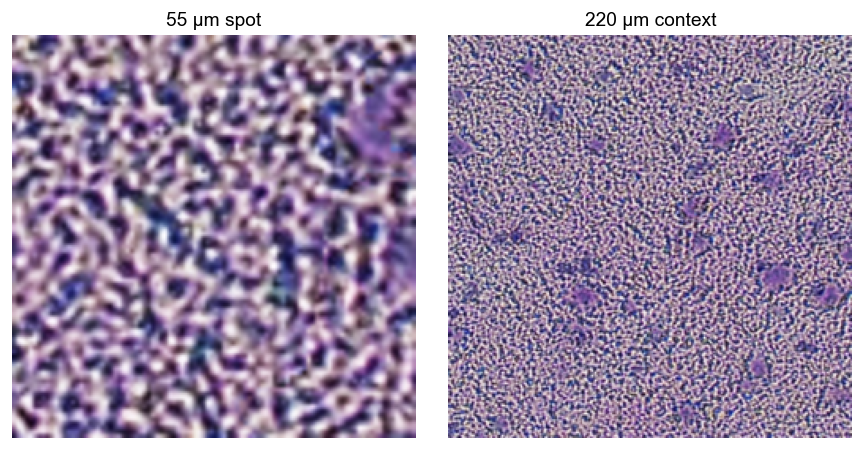

Top image-inferred genes:
MT3, FTH1, CST3, GAPDH, NRGN, TMSB10, SNAP25, TUBA1B, NDUFA4, CLU, CALM2, CALM1, COX6C, CKB, GNAS

Top matches from the deployed measured-ST atlas:


,slice_id,cell_type,matched_genes
Rank,,,
1,Human_Brain_Maynard_02082021_Visium_151672,Astrocyte,"MT3, FTH1, CST3, GAPDH, NRGN, TMSB10, SNAP25, ..."
2,Human_Brain_Maynard_02082021_Visium_151674,Neuron,"MT3, FTH1, GAPDH, NRGN, TMSB10, SNAP25, TUBA1B..."
3,Human_Brain_Maynard_02082021_Visium_151676,Astrocyte,"MT3, FTH1, CST3, GAPDH, NRGN, TMSB10, SNAP25, ..."
4,Human_Brain_Louise_02152023_Visium_Br6522_ant,Astrocyte,"MT3, FTH1, CST3, GAPDH, NRGN, TMSB10, SNAP25, ..."
5,Human_Brain_Louise_02152023_Visium_Br6522_mid,Excitatory neuron,"MT3, FTH1, CST3, GAPDH, NRGN, TMSB10, SNAP25, ..."


In [4]:
image_query = queries["image_query"]
local_view = plt.imread(DATA_DIR / image_query["local_image_file"])
context_view = plt.imread(DATA_DIR / image_query["context_image_file"])

fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.8), constrained_layout=True)
for ax, image, title in zip(
    axes,
    [local_view, context_view],
    ["55 μm spot", "220 μm context"],
):
    ax.imshow(image)
    ax.set_title(title)
    ax.set_axis_off()
plt.show()

print("Top image-inferred genes:")
print(", ".join(image_query["predicted_genes"][:15]))

full_atlas_matches = pd.DataFrame(image_query["example_results"])
print("\nTop matches from the deployed measured-ST atlas:")
full_atlas_display = full_atlas_matches[
    ["slice_id", "cell_type", "matched_genes"]
].copy()
full_atlas_display.index = np.arange(1, len(full_atlas_display) + 1)
full_atlas_display.index.name = "Rank"
display(full_atlas_display)

### Retrieve related atlas locations

The weighted rank-overlap calculation below searches the matching organ subset and returns the closest spatial locations.

In [5]:
def weighted_rank_overlap(query_genes, atlas_genes):
    atlas_rank = {
        gene.strip().upper(): rank
        for rank, gene in enumerate(str(atlas_genes).split(","))
    }
    score = 0.0
    matched = []
    for query_rank, gene in enumerate(query_genes):
        gene = gene.upper()
        atlas_gene_rank = atlas_rank.get(gene)
        if atlas_gene_rank is None:
            continue
        score += (
            (1 - min(query_rank, 49) / 60)
            * (1 - min(atlas_gene_rank, 49) / 60)
        )
        if len(matched) < 8:
            matched.append(gene)
    return score, ", ".join(matched)


image_species = image_query["species"]
image_organ = image_query["organ"]
image_candidates = spots.query(
    "species == @image_species and organ == @image_organ"
).copy()
overlap = image_candidates["top_genes"].apply(
    lambda genes: weighted_rank_overlap(image_query["predicted_genes"], genes)
)
image_candidates["rank_overlap"] = overlap.str[0]
image_candidates["matched_genes"] = overlap.str[1]
image_result = image_candidates.nlargest(8, "rank_overlap").copy()
image_result_display = image_result[
    ["cell_type", "matched_genes", "reactome_pathway"]
].head(5).copy()
image_result_display.index = np.arange(1, len(image_result_display) + 1)
image_result_display.index.name = "Rank"
display(image_result_display)

,cell_type,matched_genes,reactome_pathway
Rank,,,
1,B cell; Microglial cell; Macrophage,"FTH1, GAPDH, TMSB10, TUBA1B, COX6C, MTRNR2L12,...","Innate Immune System, Neutrophil Degranulation..."
2,Cancer cell; B cell; Fibroblast,"FTH1, CST3, GAPDH, TMSB10, SELENOW, ACTB, STMN...","Innate Immune System, Neutrophil Degranulation..."
3,Cancer cell; Oligodendrocyte; Fibroblast,"FTH1, GAPDH, TMSB10, COX6C, COX6A1, ACTB, PPIA...","Innate Immune System, Neutrophil Degranulation..."
4,B cell; Cancer cell; Astrocyte,"FTH1, GAPDH, TMSB10, TUBA1B, NDUFA4, MTRNR2L12...","Infectious Disease, Innate Immune System, FCGR..."
5,Cancer cell; Fibroblast; Oligodendrocyte,"FTH1, GAPDH, TMSB10, NDUFA4, COX6C, ACTB, PPIA...","Innate Immune System, Cytokine Signaling in Im..."


## Verify the calculations

The checks confirm that every atlas vector has one metadata row and that the returned similarities are sorted.

In [6]:
assert len(spots) == len(X) == 2_250
assert not spots["spot_id"].duplicated().any()
for result in retrievals.values():
    values = result["cosine_similarity"].to_numpy()
    assert np.all(values[:-1] >= values[1:])
assert (DATA_DIR / image_query["local_image_file"]).exists()
assert (DATA_DIR / image_query["context_image_file"]).exists()
assert len(image_query["predicted_genes"]) == 50
assert full_atlas_matches["cell_type"].notna().all()
assert image_result["rank_overlap"].is_monotonic_decreasing
print("Checks passed for 2,250 spots, text retrieval and H&E retrieval.")

Checks passed for 2,250 spots, text retrieval and H&E retrieval.


## Continue in the Agent Module

Open a retrieved atlas location in Spot Chat to inspect its molecular profile and ask follow-up questions.